<a href="https://colab.research.google.com/github/luckyKumar37/fashion_mnist_with_pytroch/blob/main/CNN_on_fashion_mnist_with_pytroch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset,Dataset,DataLoader,random_split
from torchvision import datasets,transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random


def set_seed(seed=42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  random.seed(seed)
  np.random.seed(seed)


set_seed()

In [17]:
transform=transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root='/content/',
    train=True,
    download=True,
    transform=transform
)

In [18]:
train_size = int(0.8*len(train_dataset))
val_size = len(train_dataset) - train_size


train_dataset,val_dataset  = random_split(
    train_dataset,
    [train_size,val_size]
)


train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False
)



In [19]:
test_dataset = datasets.FashionMNIST(
    root = '/content/',
    train = False,
    download=True,
    transform = transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)




In [20]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

48000
12000
10000


In [21]:
image,label = train_dataset[0]

image.shape


torch.Size([1, 28, 28])

In [22]:
class CNN(nn.Module):
  def __init__(self,input_size):
    super().__init__()

    self.Extraction = nn.Sequential(
        nn.Conv2d(input_size,32,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2),

        nn.Conv2d(32,64,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(7*7*64,128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64,10)

    )

  def forward(self,x):
    x = self.Extraction(x)

    return self.classifier(x)

In [23]:
def init_weights(m):

    if isinstance(m, nn.Conv2d):
        nn.init.kaiming_normal_(
            m.weight,
            mode='fan_out',
            nonlinearity='relu'
        )

        if m.bias is not None:
            nn.init.zeros_(m.bias)

    elif isinstance(m, nn.Linear):

        if m.out_features == 10:
            # Output layer
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

        else:
            # Hidden layers
            nn.init.kaiming_normal_(
                m.weight,
                nonlinearity='relu'
            )
            nn.init.zeros_(m.bias)

In [24]:

image,label = train_dataset[0]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


model = CNN(image.shape[0]).to(device)

model.apply(init_weights)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.5
)



In [25]:
pip install torchinfo


In [26]:
from torchinfo import summary

summary(model,input_size=(64,1,28,28))

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [64, 10]                  --
├─Sequential: 1-1                        [64, 64, 7, 7]            --
│    └─Conv2d: 2-1                       [64, 32, 28, 28]          320
│    └─ReLU: 2-2                         [64, 32, 28, 28]          --
│    └─BatchNorm2d: 2-3                  [64, 32, 28, 28]          64
│    └─MaxPool2d: 2-4                    [64, 32, 14, 14]          --
│    └─Conv2d: 2-5                       [64, 64, 14, 14]          18,496
│    └─ReLU: 2-6                         [64, 64, 14, 14]          --
│    └─BatchNorm2d: 2-7                  [64, 64, 14, 14]          128
│    └─MaxPool2d: 2-8                    [64, 64, 7, 7]            --
├─Sequential: 1-2                        [64, 10]                  --
│    └─Flatten: 2-9                      [64, 3136]                --
│    └─Linear: 2-10                      [64, 128]                 401,536
│   

In [28]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

patience = 5
best_val_loss = float('inf')
counter = 0

epochs = 20

for epoch in range(epochs):

  # training

  model.train()

  train_loss = 0
  train_correct = 0
  train_total = 0

  for X_batch,y_batch in train_loader:

    X_batch,y_batch = X_batch.to(device),y_batch.to(device)

    output = model(X_batch)

    loss = criterion(output,y_batch)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


    train_loss += loss.item()

    prediction = torch.argmax(output,dim=1)

    train_correct += (prediction == y_batch).sum().item()

    train_total += y_batch.size(0)

  train_loss /= len(train_loader)
  train_accuracy = train_correct/train_total


  # validation

  model.eval()

  val_loss = 0
  val_correct = 0
  val_total = 0

  with torch.no_grad():

    for X_batch,y_batch in val_loader:

      X_batch,y_batch = X_batch.to(device),y_batch.to(device)

      output = model(X_batch)

      loss = criterion(output,y_batch)

      val_loss += loss.item()

      prediction = torch.argmax(output,dim=1)

      val_correct += (prediction == y_batch).sum().item()

      val_total += y_batch.size(0)


  val_loss /=len(val_loader)
  val_accuracy = val_correct/val_total


  train_losses.append(train_loss)
  train_accuracies.append(train_accuracy)

  val_losses.append(val_loss)
  val_accuracies.append(val_accuracy)

  # scheduler
  scheduler.step(val_loss)


  # early stopping

  if val_loss < best_val_loss:

    best_val_loss = val_loss
    counter = 0

    torch.save(
        model.state_dict(),
        'best_model.pth'
    )

  else:
    counter+=1

    if counter >= patience:

      print('Early stopping triggered')
      break


  current_lr = optimizer.param_groups[0]['lr']


  print(
      f"Epoch [{epoch+1}/{epochs}] "
      f"Train Loss: {train_loss:.4f} "
      f"Val Loss: {val_loss:.4f} "
      f"Train Acc: {train_accuracy:.4f} "
      f"Val Acc: {val_accuracy:.4f}"
      f"LR: {current_lr:.6f}"
  )







Epoch [1/20] Train Loss: 0.2196 Val Loss: 0.2373 Train Acc: 0.9211 Val Acc: 0.9163LR: 0.001000
Epoch [2/20] Train Loss: 0.2011 Val Loss: 0.2464 Train Acc: 0.9281 Val Acc: 0.9134LR: 0.001000
Epoch [3/20] Train Loss: 0.1946 Val Loss: 0.2490 Train Acc: 0.9301 Val Acc: 0.9175LR: 0.001000
Epoch [4/20] Train Loss: 0.1836 Val Loss: 0.2525 Train Acc: 0.9341 Val Acc: 0.9163LR: 0.000500
Epoch [5/20] Train Loss: 0.1437 Val Loss: 0.2223 Train Acc: 0.9477 Val Acc: 0.9259LR: 0.000500
Epoch [6/20] Train Loss: 0.1325 Val Loss: 0.2336 Train Acc: 0.9516 Val Acc: 0.9245LR: 0.000500
Epoch [7/20] Train Loss: 0.1206 Val Loss: 0.2594 Train Acc: 0.9563 Val Acc: 0.9203LR: 0.000500
Epoch [8/20] Train Loss: 0.1114 Val Loss: 0.2431 Train Acc: 0.9587 Val Acc: 0.9246LR: 0.000500
Epoch [9/20] Train Loss: 0.1059 Val Loss: 0.2547 Train Acc: 0.9611 Val Acc: 0.9273LR: 0.000250
Early stopping triggered


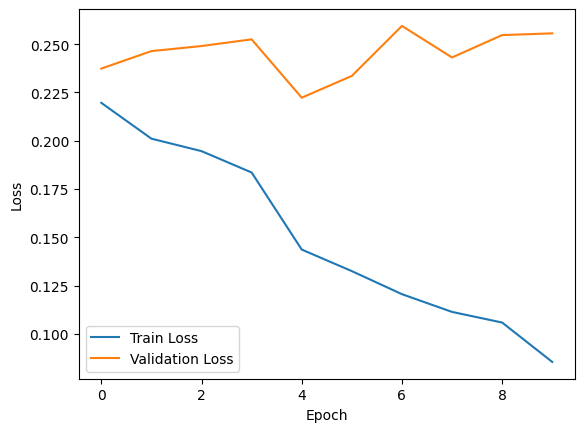

In [29]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

model.load_state_dict(
    torch.load('best_model.pth')

)

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)


        predictions = torch.argmax(outputs, dim=1)


        probabilities = torch.softmax(outputs, dim=1)

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            y_batch.cpu().numpy()
        )

        all_probs.extend(
            probabilities.cpu().numpy()
        )



accuracy = accuracy_score(
    all_labels,
    all_preds
)



precision = precision_score(
    all_labels,
    all_preds,
    average="weighted"
)



recall = recall_score(
    all_labels,
    all_preds,
    average="weighted"
)



f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted"
)



auc = roc_auc_score(
    all_labels,
    all_probs,
    multi_class="ovr",
    average="weighted"
)


print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", auc)



print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names = [
            "T-shirt/top",
            "Trouser",
            "Pullover",
            "Dress",
            "Coat",
            "Sandal",
            "Shirt",
            "Sneaker",
            "Bag",
            "Ankle boot"
        ]
    )
)



print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_labels,
        all_preds
    )
)


Accuracy : 0.9224
Precision: 0.9229604315052972
Recall   : 0.9224
F1 Score : 0.9224753637823966
ROC-AUC  : 0.9951209611111111

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.91      0.87      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.91      0.87      0.89      1000
       Dress       0.92      0.93      0.92      1000
        Coat       0.89      0.86      0.88      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.76      0.77      0.76      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


Confusion Matrix:
[[905   0  12   8   3   1  69   0   2   0]
 [  1 986   0   8   1   0   1